In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

In [2]:
df = pd.read_csv("urban_water_dataset.csv")
df.head()

,Household_Size,Income_Level,Garden_Area,Rainfall_mm,Temperature_C,Seasonal_Index,Water_Price,Appliance_Count,Leakage_Factor,Daily_Liters_Used,Per_Person_Usage,Garden_Impact,Water_Intensity,Usage_Class
0,7,45525,226,141.071267,33.424771,1.252923,6.422917,6,0.051970,1529.126460,218.446637,283.160593,6.736240,1
1,4,99818,422,83.494911,30.585873,1.214904,8.260259,7,0.382138,1345.517271,336.379318,512.689322,3.180892,1
2,5,34334,71,151.614700,23.534197,1.104200,5.777185,7,0.133420,1125.495944,225.099189,78.398183,15.631888,0
3,7,82767,242,78.646140,22.580100,0.681165,2.206026,10,0.104578,1565.120346,223.588621,164.841973,6.440824,1
4,3,26644,17,165.272637,12.177689,0.809873,8.168883,11,0.116506,774.072215,258.024072,13.767843,43.004012,0


In [3]:
df.describe()

,Household_Size,Income_Level,Garden_Area,Rainfall_mm,Temperature_C,Seasonal_Index,Water_Price,Appliance_Count,Leakage_Factor,Daily_Liters_Used,Per_Person_Usage,Garden_Impact,Water_Intensity,Usage_Class
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3.978500,59635.211833,247.740667,99.742870,24.973274,1.005687,5.973718,7.451500,0.202076,1094.264030,355.686265,249.056728,12.348823,0.464333
std,1.993916,23307.222142,145.012898,57.113345,8.708971,0.230825,2.306983,4.023599,0.116411,274.335269,202.999716,159.580486,43.814928,0.498768
min,1.000000,20002.000000,0.000000,0.023729,10.000279,0.600016,2.000819,1.000000,0.000037,132.972821,114.987490,0.000000,1.104413,0.000000
25%,2.000000,39473.000000,119.000000,50.587439,17.349875,0.809811,3.992922,4.000000,0.102065,893.435946,222.768610,115.038312,3.098664,0.000000
50%,4.000000,59228.000000,251.000000,99.626895,24.860741,1.010230,6.000745,7.000000,0.202721,1098.519185,275.808108,236.536952,4.423538,0.000000
75%,6.000000,79968.750000,372.000000,147.750998,32.572507,1.205457,7.976726,11.000000,0.304397,1293.163903,402.862263,362.366922,8.387396,1.000000
max,7.000000,99993.000000,499.000000,199.978533,39.990845,1.399979,9.998499,14.000000,0.399919,1902.301277,1250.816643,680.802042,1232.882471,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_Size     6000 non-null   int64  
 1   Income_Level       6000 non-null   int64  
 2   Garden_Area        6000 non-null   int64  
 3   Rainfall_mm        6000 non-null   float64
 4   Temperature_C      6000 non-null   float64
 5   Seasonal_Index     6000 non-null   float64
 6   Water_Price        6000 non-null   float64
 7   Appliance_Count    6000 non-null   int64  
 8   Leakage_Factor     6000 non-null   float64
 9   Daily_Liters_Used  6000 non-null   float64
 10  Per_Person_Usage   6000 non-null   float64
 11  Garden_Impact      6000 non-null   float64
 12  Water_Intensity    6000 non-null   float64
 13  Usage_Class        6000 non-null   int64  
dtypes: float64(9), int64(5)
memory usage: 656.4 KB


In [5]:
df.isnull().sum()

Household_Size       0
Income_Level         0
Garden_Area          0
Rainfall_mm          0
Temperature_C        0
Seasonal_Index       0
Water_Price          0
Appliance_Count      0
Leakage_Factor       0
Daily_Liters_Used    0
Per_Person_Usage     0
Garden_Impact        0
Water_Intensity      0
Usage_Class          0
dtype: int64

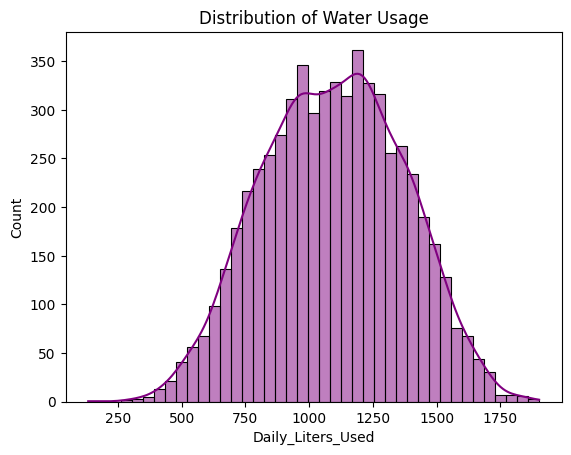

In [6]:
plt.figure()
sns.histplot(df["Daily_Liters_Used"], kde=True, color="purple")
plt.title("Distribution of Water Usage")
plt.show()

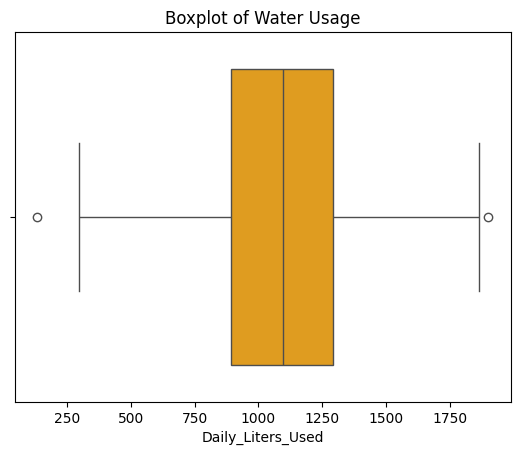

In [7]:
plt.figure()
sns.boxplot(x=df["Daily_Liters_Used"], color="orange")
plt.title("Boxplot of Water Usage")
plt.show()

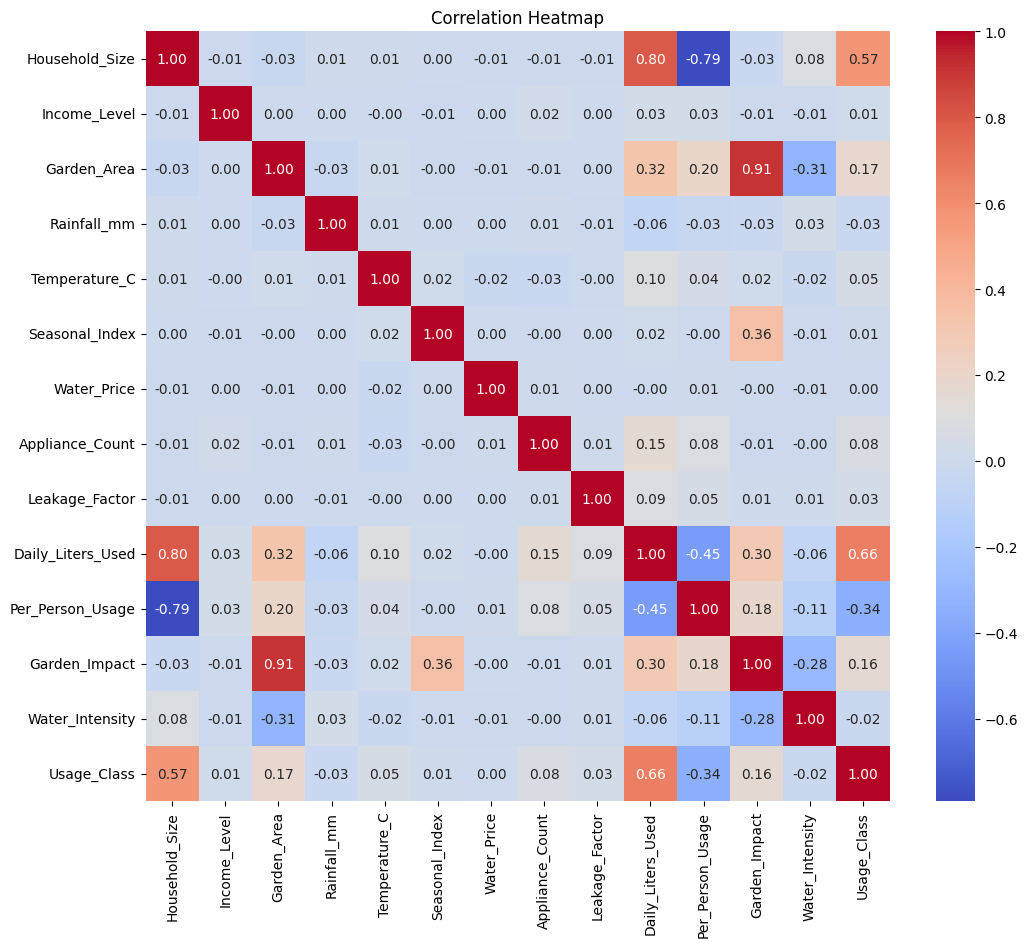

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
X = df.drop(["Daily_Liters_Used", "Usage_Class"], axis=1)
y_reg = df["Daily_Liters_Used"]
y_clf = df["Usage_Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

# Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)

print("MSE:", mean_squared_error(y_test_reg, y_pred_lr))
print("R2:", r2_score(y_test_reg, y_pred_lr))



MSE: 12443.82329547693
R2: 0.838680024357165


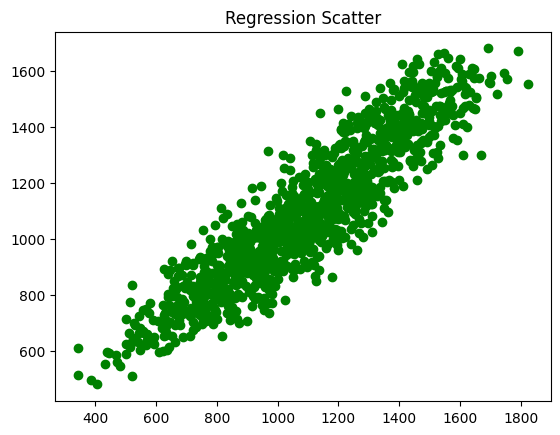

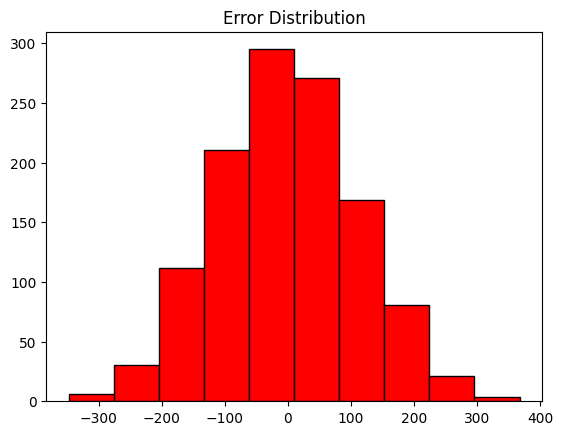

In [11]:
plt.figure()
plt.scatter(y_test_reg, y_pred_lr, color="green")
plt.title("Regression Scatter")
plt.show()

plt.figure()
plt.hist(y_test_reg - y_pred_lr, color="red",edgecolor="black")
plt.title("Error Distribution")
plt.show()

## KNN

In [12]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train_clf)
y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_knn))
print("F1:", f1_score(y_test_clf, y_pred_knn))
print("Recall:", recall_score(y_test_clf, y_pred_knn))

Accuracy: 0.7616666666666667
F1: 0.7361623616236163
Recall: 0.7163375224416517


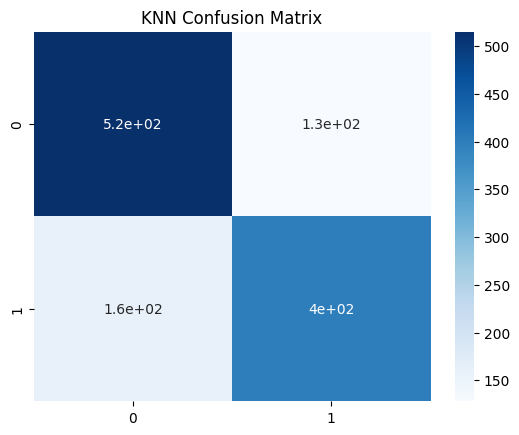

In [13]:
cm = confusion_matrix(y_test_clf, y_pred_knn)
plt.figure()
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

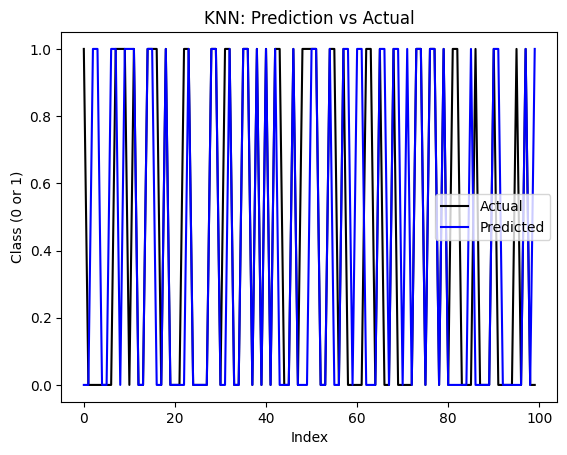

In [26]:
plt.figure()

plt.plot(y_test_clf.values[:100], label="Actual", color="black")
plt.plot(y_pred_knn[:100], label="Predicted", color="blue")

plt.xlabel("Index")
plt.ylabel("Class (0 or 1)")
plt.title("KNN: Prediction vs Actual")

plt.legend()
plt.show()

## SVM

In [14]:
svm = SVC()
svm.fit(X_train, y_train_clf)
y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_svm))
print("F1:", f1_score(y_test_clf, y_pred_svm))
print("Recall:", recall_score(y_test_clf, y_pred_svm))

Accuracy: 0.8366666666666667
F1: 0.8168224299065421
Recall: 0.7845601436265709


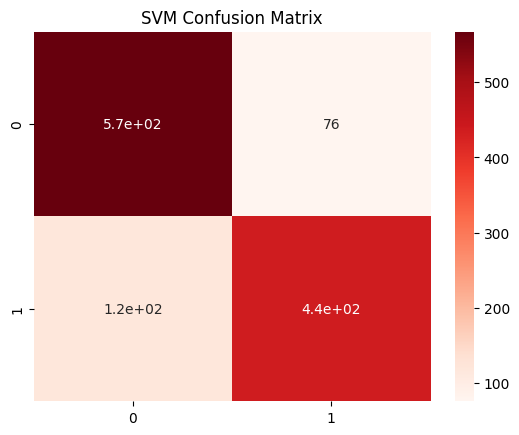

In [15]:
cm = confusion_matrix(y_test_clf, y_pred_svm)
plt.figure()
sns.heatmap(cm, annot=True, cmap="Reds")
plt.title("SVM Confusion Matrix")
plt.show()

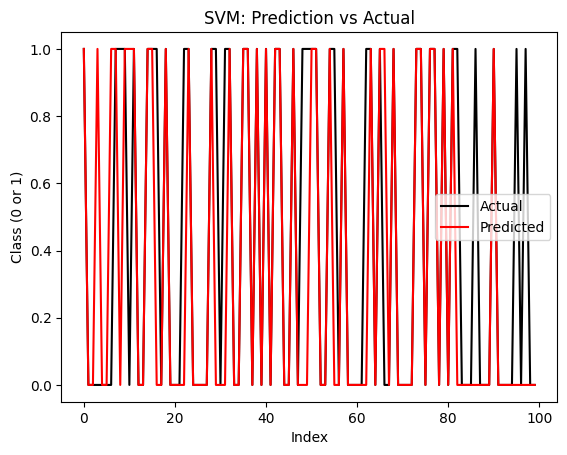

In [27]:
plt.figure()

plt.plot(y_test_clf.values[:100], label="Actual", color="black")
plt.plot(y_pred_svm[:100], label="Predicted", color="red")

plt.xlabel("Index")
plt.ylabel("Class (0 or 1)")
plt.title("SVM: Prediction vs Actual")

plt.legend()
plt.show()

## Decision Tree

In [16]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train_clf)
y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_dt))
print("F1:", f1_score(y_test_clf, y_pred_dt))
print("Recall:", recall_score(y_test_clf, y_pred_dt))

Accuracy: 0.88
F1: 0.8646616541353384
Recall: 0.8258527827648114


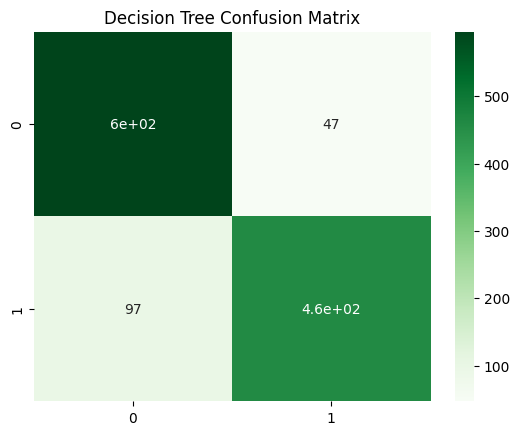

In [17]:
cm = confusion_matrix(y_test_clf, y_pred_dt)
plt.figure()
sns.heatmap(cm, annot=True, cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

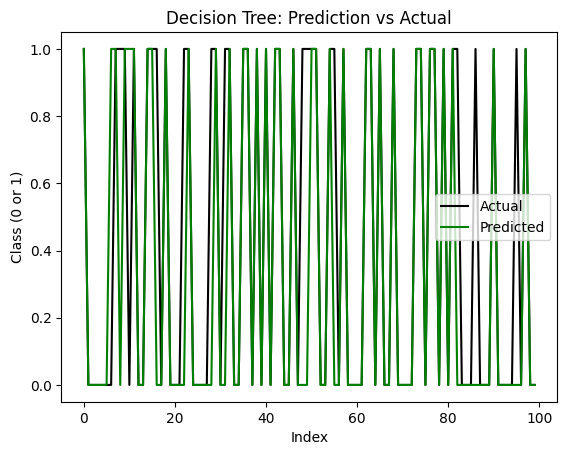

In [28]:
plt.figure()

plt.plot(y_test_clf.values[:100], label="Actual", color="black")
plt.plot(y_pred_dt[:100], label="Predicted", color="green")

plt.xlabel("Index")
plt.ylabel("Class (0 or 1)")
plt.title("Decision Tree: Prediction vs Actual")

plt.legend()
plt.show()

## Final Comparison

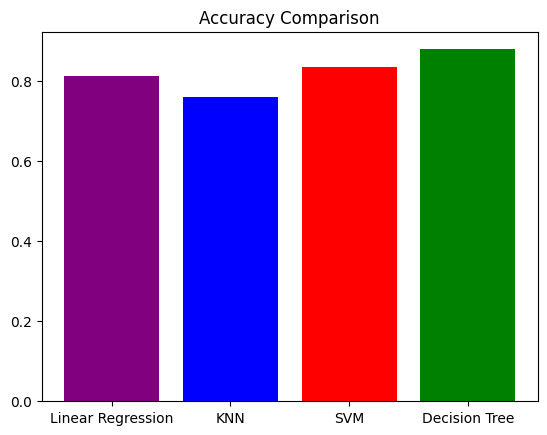

In [18]:
y_pred_lr_class = (y_pred_lr > np.median(y_test_reg)).astype(int)

models = ["Linear Regression", "KNN", "SVM", "Decision Tree"]
accuracy = [
    accuracy_score(y_test_clf, y_pred_lr_class),
    accuracy_score(y_test_clf, y_pred_knn),
    accuracy_score(y_test_clf, y_pred_svm),
    accuracy_score(y_test_clf, y_pred_dt)
]

plt.figure()
plt.bar(models, accuracy, color=["purple","blue","red","green"])
plt.title("Accuracy Comparison")
plt.show()

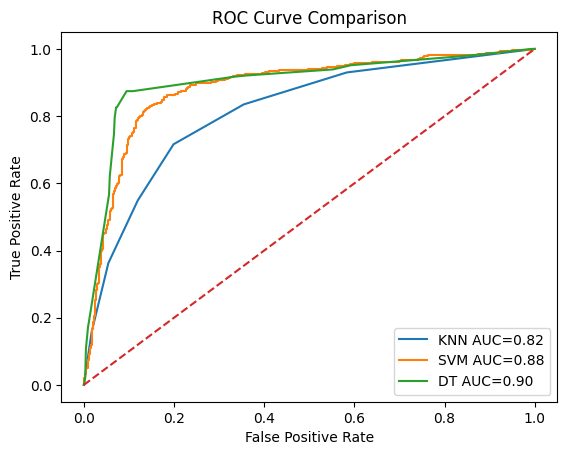

In [19]:

from sklearn.metrics import roc_curve, auc

# probabilities
knn_prob = knn.predict_proba(X_test)[:,1]
svm_prob = svm.predict_proba(X_test)[:,1] if hasattr(svm, "predict_proba") else svm.decision_function(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

# ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, knn_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test_clf, svm_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test_clf, dt_prob)

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC={auc_knn:.2f}")
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC={auc_svm:.2f}")
plt.plot(fpr_dt, tpr_dt, label=f"DT AUC={auc_dt:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


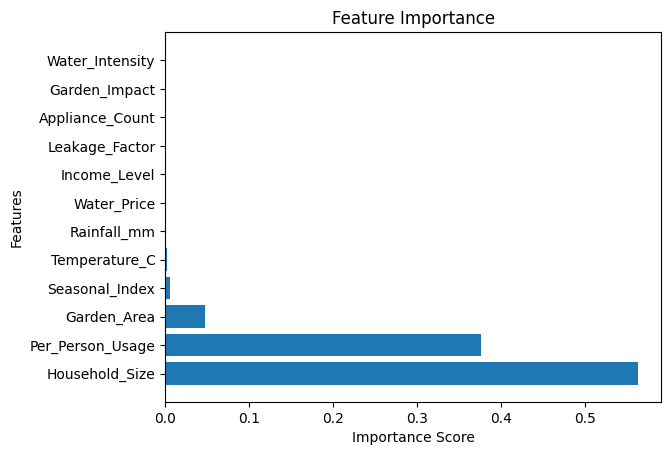

In [20]:

importance = dt.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()


In [21]:

from sklearn.metrics import precision_score

y_pred_lr_class = (y_pred_lr > np.median(y_test_reg)).astype(int)

models = ["LR","KNN","SVM","DT"]

accuracy = [
    accuracy_score(y_test_clf, y_pred_lr_class),
    accuracy_score(y_test_clf, y_pred_knn),
    accuracy_score(y_test_clf, y_pred_svm),
    accuracy_score(y_test_clf, y_pred_dt)
]

f1 = [
    f1_score(y_test_clf, y_pred_lr_class),
    f1_score(y_test_clf, y_pred_knn),
    f1_score(y_test_clf, y_pred_svm),
    f1_score(y_test_clf, y_pred_dt)
]

recall = [
    recall_score(y_test_clf, y_pred_lr_class),
    recall_score(y_test_clf, y_pred_knn),
    recall_score(y_test_clf, y_pred_svm),
    recall_score(y_test_clf, y_pred_dt)
]

precision = [
    precision_score(y_test_clf, y_pred_lr_class),
    precision_score(y_test_clf, y_pred_knn),
    precision_score(y_test_clf, y_pred_svm),
    precision_score(y_test_clf, y_pred_dt)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "F1": f1,
    "Recall": recall,
    "Precision": precision
})

print(comparison)


  Model  Accuracy        F1    Recall  Precision
0    LR  0.813333  0.798561  0.797127   0.800000
1   KNN  0.761667  0.736162  0.716338   0.757116
2   SVM  0.836667  0.816822  0.784560   0.851852
3    DT  0.880000  0.864662  0.825853   0.907298


## Best Model Selection

In [22]:

best_index = comparison["F1"].idxmax()
best_model = comparison.iloc[best_index]

print("Best Model based on F1 Score:")
print(best_model)


Best Model based on F1 Score:
Model              DT
Accuracy         0.88
F1           0.864662
Recall       0.825853
Precision    0.907298
Name: 3, dtype: object
